---
title: Dataset Explorations
date: 09/2025
authors:
  - name: James Butler
    affiliations: ucb
  - name: Michelle Maclennan
    affiliation: bas
  - name: Fernando Pérez
    affiliation: ucb
  - name: Jon McAuliffe
    affiliation: ucb
affiliations:
  - id: ucb
    institution: University of California Berkeley
    ror: https://ror.org/01an7q238
    department: Statistics
  - id: bas
    institution: British Antarctic Survey
    ror: https://ror.org/01rhff309
---

With our constructed dataset of AR events, novel insights about the climatological behavior of past Antarctic ARs at the level of individual events can be easily garnered. This notebook walks through some of these findings.

In [6]:
# package imports
from artools.loading_utils import load_ais, load_cell_areas, load_catalog
from artools.attribute_utils import *
from artools.display_utils import *
import xarray as xr
from matplotlib.cm import Set3
from matplotlib import pyplot as plt
import cartopy.crs as ccrs
import pandas as pd
import matplotlib.path as mpath
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
import seaborn as sns
from scipy import stats
import numpy as np

In [7]:
# load up input products
ais_mask = load_ais()
cell_areas = load_cell_areas()

In [13]:
storms_temp.shape

(7, 1)

In [8]:
# load up datasets
storms_setting = pd.read_hdf('../output/data_products/storms_setting.h5')
storms_temp = pd.read_csv('../output/data_products/results_T2M.csv', index_col='cluster')
storms_precip = pd.read_csv('../output/data_products/results_precip.csv', index_col='cluster')

dataset = pd.concat([storms_setting, storms_temp, storms_precip], axis=1)

## Spatial and Temporal Trends

We first characterize AR frequencies and their temporal and spatial trends. Region definitions are taken from [Baiman et al. (2024)](https://doi.org/10.1038/s43247-024-01307-9). An AR's landfalling region is the region in which the footprint spent the most cumulative time and space; in this way, the region we assign to each AR can be considered the one the AR impacted the most.

Let's first explore regional trends for AR landfalls, plotting AR centroid trajectories, as well as landfall counts.

In [9]:
color_mapping = {'East 1': Set3(4), 'East 2': Set3(5), 'West': Set3(9)}

# extract masks for regions and region areas
region_defs = {'West': [-150, -30], 
               'East 1': [-30, 75],
               'East 2': [75, -150]}
region_masks = find_region_masks(region_defs, ais_mask)
region_areas = {}

for region, mask in region_masks.items():
    region_areas[region] = mask.dot(cell_areas).values/(10**6)

AttributeError: 'Series' object has no attribute 'trajectory'

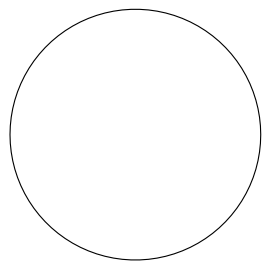

In [10]:
fig = plt.figure(figsize=(11,4))
ax1 = plt.subplot(131, projection=ccrs.Stereographic(central_longitude=0., central_latitude=-90.))

# add trajectories
for index, row in dataset.iterrows():
    trajectory = row.trajectory
    ax1.plot(trajectory.avg_lon, trajectory.avg_lat, transform=ccrs.Geodetic(), color=color_mapping[row.region], alpha=0.1)

# add region labels
for label in region_defs.keys():
    if label == 'East 2':
        ax1.text((region_defs[label][0] + region_defs[label][1])/2 + 180, -53, label, fontsize=14, horizontalalignment='center', bbox=dict(facecolor='black', edgecolor=color_mapping[label], boxstyle='round'), transform=ccrs.PlateCarree(), color=color_mapping[label], zorder=40)
    else:
        ax1.text((region_defs[label][0] + region_defs[label][1])/2, -53, label, fontsize=14, horizontalalignment='center', bbox=dict(facecolor='black', edgecolor=color_mapping[label], boxstyle='round'), transform=ccrs.PlateCarree(), color=color_mapping[label], zorder=40)

# add geographic features to trajectory map
ice_shelf_poly = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_polys', '50m',edgecolor='none',facecolor='lightcyan') # 10m, 50m, 110m
ax1.add_feature(ice_shelf_poly,linewidth=3)
ice_shelf_line = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_lines', '50m',edgecolor='black',facecolor='none') # 10m, 50m, 110m
ax1.add_feature(ice_shelf_line,linewidth=1,zorder=13)
ax1.coastlines(resolution='110m',linewidth=1,zorder=32)
ax1.set_extent([-180,180,-90,-42], ccrs.PlateCarree())
ax1.set_title('(a) Landfalls by Region')

    
# add landfalling barcharts
ax2 = plt.subplot(132)
sns.countplot(dataset, x='region', ax=ax2, order=['West', 'East 1', 'East 2'], hue='region', palette=color_mapping)
ax2.set_title('(b) Landfall Counts')
ax2.set_ylabel('ARs')
ax2.set_xlabel('')

# add region normalized barcharts
ax3 = plt.subplot(133)
region_df = dataset.groupby('region').size()
region_df = pd.concat([region_df.rename('count'), pd.Series(region_areas).rename('area')], axis=1, names=['region', 'area'])
region_df['storms_per_area'] = region_df['count']/region_df['area']
sns.barplot(data=region_df, x=region_df.index, y='storms_per_area', ax=ax3, order=['West', 'East 1', 'East 2'], hue=region_df.index, palette=color_mapping)
ax3.set_title('(c) Landfall Counts/Region Area')
ax3.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
ax3.set_ylabel(r'ARs/km$^2$')
ax3.set_xlabel('')

fig.tight_layout(pad=1)
fig.savefig('../output/plots/regional_counts.png', dpi=300)

We see that West Antarctica and East Antarctica 2 both have the most landfalls, but that West Antarctica by far has the most landfalls per unit area of the regions. Now, let's look at temporal trends. Let's show some summary statistics of yearly AR counts.

In [16]:
years = dataset.start_date.dt.year
dataset['landfalling_year'] = years
year_df = dataset.groupby('landfalling_year', as_index=False).size()

In [17]:
year_df['size'].describe()

count    43.000000
mean     73.604651
std      10.741862
min      47.000000
25%      68.000000
50%      73.000000
75%      80.500000
max      99.000000
Name: size, dtype: float64

Now, let's observe yearly trends in AR counts, both Antarctic-wide and across regions.

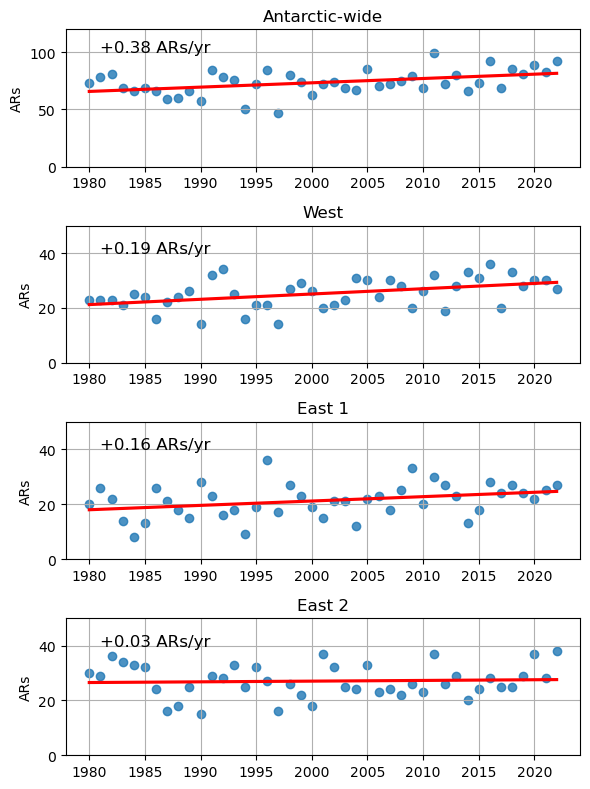

In [18]:
fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(6,8))

cur_ax = axs[0]

sns.regplot(data=year_df, x='landfalling_year', y='size', ci=None, line_kws={"color": "red"}, ax=cur_ax)
ar_rate = round(stats.linregress(year_df.landfalling_year, year_df['size'])[0], 2)
text = f'+{ar_rate} ARs/yr'
cur_ax.set_title('Antarctic-wide')
cur_ax.set_ylim([0, 120])
cur_ax.set_xticks(np.arange(1980, 2021, 5))
cur_ax.text(1981, 100, s=text, fontsize=12)
cur_ax.set_xlabel('')
cur_ax.set_ylabel('ARs')
cur_ax.grid(True)

year_df = dataset.groupby(['landfalling_year', 'region'], as_index=False).size()

coord = 1
for label in region_masks.keys():
    cur_ax =axs[coord%4]

    year_region_df = year_df[year_df.region == label]
    sns.regplot(data=year_region_df, x='landfalling_year', y='size', ci=None, line_kws={"color": "red"}, ax=cur_ax)
    ar_rate = round(stats.linregress(year_region_df.landfalling_year, year_region_df['size'])[0], 2)
    text = f'+{ar_rate} ARs/yr'
    cur_ax.set_title(label)
    cur_ax.set_ylim([0, 50])
    cur_ax.set_xticks(np.arange(1980, 2021, 5))
    cur_ax.text(1981, 40, s=text, fontsize=12)
    cur_ax.set_xlabel('')
    cur_ax.set_ylabel('ARs')
    cur_ax.grid(True)

    coord += 1

fig.tight_layout()

fig.savefig('../output/plots/regional_count_trends.png', dpi=300)

In [19]:
year_df.groupby('region')['size'].describe()

,count,mean,std,min,25%,50%,75%,max
region,,,,,,,,
East 1,43.0,21.302326,6.049537,8.0,18.0,22.0,25.5,36.0
East 2,43.0,27.046512,5.975958,15.0,24.0,26.0,32.0,38.0
West,43.0,25.255814,5.473282,14.0,21.0,25.0,30.0,36.0


We find that, overall, the number of AR landfalls is increasing year after year, with a positive association in West Antarctica, East 1, but not much of a discernible positive trend in East 2. 

## Impacts

In our dataset, we also computed impact quantities, such as maximum 2m-temperature anomaly over the Antarctic ice sheet, cumulative snowfall over the ice sheet, and cumulative rainfall. Let's explore some of these findings now as well!

,data_array,is_landfalling,max_area,mean_landfalling_area,cumulative_landfalling_area,duration,start_date,end_date,max_south_extent,trajectory,region,max_T2M_anomaly_ais,cumulative_rainfall_ais,cumulative_snowfall_ais,landfalling_year
cluster,,,,,,,,,,,,,,,
8863,,True,5382746,1544442,7336100,114,2022-03-13 15:00:00,2022-03-18 06:00:00,-85.000000,,East 2,40.972366,679248752323.945312,71251741807411.062500,2022

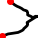

In [20]:
display_catalog(dataset.loc[[dataset.cumulative_snowfall_ais.idxmax()]])

The storm that produced the most cumulative snowfall is the one from the March 2022 heat wave, reported in @wille_extraordinary_2024 .

,data_array,is_landfalling,max_area,mean_landfalling_area,cumulative_landfalling_area,duration,start_date,end_date,max_south_extent,trajectory,region,max_T2M_anomaly_ais,cumulative_rainfall_ais,cumulative_snowfall_ais,landfalling_year
cluster,,,,,,,,,,,,,,,
8863,,True,5382746,1544442,7336100,114,2022-03-13 15:00:00,2022-03-18 06:00:00,-85.000000,,East 2,40.972366,679248752323.945312,71251741807411.062500,2022

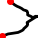

In [21]:
display_catalog(dataset.loc[[dataset.max_T2M_anomaly_ais.idxmax()]])

This storm also produced the highest temperature anomaly of all ARs, which of course was the primary subject of the above paper.

,data_array,is_landfalling,max_area,mean_landfalling_area,cumulative_landfalling_area,duration,start_date,end_date,max_south_extent,trajectory,region,max_T2M_anomaly_ais,cumulative_rainfall_ais,cumulative_snowfall_ais,landfalling_year
cluster,,,,,,,,,,,,,,,
8845,,True,3877096,712098,2759381,93,2022-02-05 12:00:00,2022-02-09 06:00:00,-85.000000,,West,20.089249,3441222736004.801270,33601025113350.265625,2022

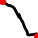

In [22]:
display_catalog(dataset.loc[[dataset.cumulative_rainfall_ais.idxmax()]])

The storm that produced the most rainfall is the one reported in @gorodetskaya_record-high_2023 . In this paper, this storm was analyzed because it produced record high temperature measurements on the Antarctic Peninsula.

Now, let's look at some event-level visualizations and statistics of impacts. First, we'll convert the snowfall and rainfall measurements to gigatons.

In [23]:
dataset['cumulative_snowfall_ais'] = dataset['cumulative_snowfall_ais']/(10**(12))
dataset['cumulative_rainfall_ais'] = dataset['cumulative_rainfall_ais']/(10**(12))

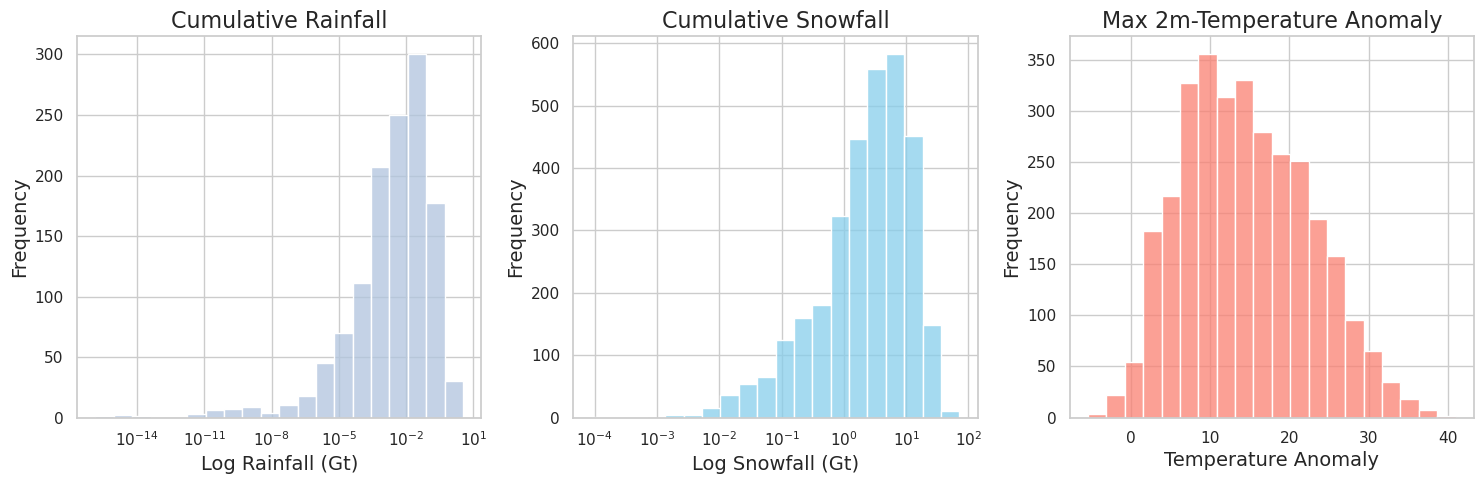

In [25]:
sns.set_theme(style="whitegrid")

# create a figure with 3 subplots arranged in 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# histogram 1: cumulative rainfall (log scale)
sns.histplot(data=dataset, x='cumulative_rainfall_ais', bins=20, color='lightsteelblue', log_scale=True, ax=axes[0])
axes[0].set_title('Cumulative Rainfall', fontsize=16)
axes[0].set_xlabel('Log Rainfall (Gt)', fontsize=14)
axes[0].set_ylabel('Frequency', fontsize=14)

# histogram 2: cumulative snowfall (log scale)
sns.histplot(data=dataset, x='cumulative_snowfall_ais', bins=20, color='skyblue', log_scale=True, ax=axes[1])
axes[1].set_title('Cumulative Snowfall', fontsize=16)
axes[1].set_xlabel('Log Snowfall (Gt)', fontsize=14)
axes[1].set_ylabel('Frequency', fontsize=14)

# histogram 3: max T2M anomaly (untransformed)
sns.histplot(data=dataset, x='max_T2M_anomaly_ais', bins=20, color='salmon', ax=axes[2])
axes[2].set_title('Max 2m-Temperature Anomaly', fontsize=16)
axes[2].set_xlabel('Temperature Anomaly', fontsize=14)
axes[2].set_ylabel('Frequency', fontsize=14)

# automatically adjust spacing between subplots
plt.tight_layout()

# display the plot
fig.savefig('../output/plots/impact_distributions.png', dpi=300)

In [26]:
(dataset['cumulative_rainfall_ais'] == 0).sum()

np.int64(1914)

We find that more than half of the ARs identified bring no rainfall at all. For ease of plotting this, we drop these observations from the plot and plot snowfall and rainfall on a log scale, as both distributions are very heavy right-tailed. We find that storms in general produce more snowfall than they do rainfall, which is in line with previous work. Further, we find that the vast majority of ARs have positive 2m-temperature anomalies, aligning with previous knowledge about the mechanisms of AR landfalls, and that this distribution is much less heavy tailed than the precipitation ones.

In [27]:
round(dataset['cumulative_rainfall_ais'].describe(), 4)

count    3165.0000
mean        0.0241
std         0.1233
min         0.0000
25%         0.0000
50%         0.0000
75%         0.0014
max         3.4412
Name: cumulative_rainfall_ais, dtype: float64

In [28]:
round(dataset['cumulative_snowfall_ais'].describe(), 2)

count    3165.00
mean        5.31
std         6.46
min         0.00
25%         0.87
50%         2.98
75%         7.46
max        71.25
Name: cumulative_snowfall_ais, dtype: float64

In [29]:
round(dataset['max_T2M_anomaly_ais'].describe(), 2)

count    3165.00
mean       14.57
std         7.97
min        -5.42
25%         8.43
50%        13.97
75%        20.35
max        40.97
Name: max_T2M_anomaly_ais, dtype: float64

Let's further look at disaggregations across regions to see if there's any interaction between region and impact.

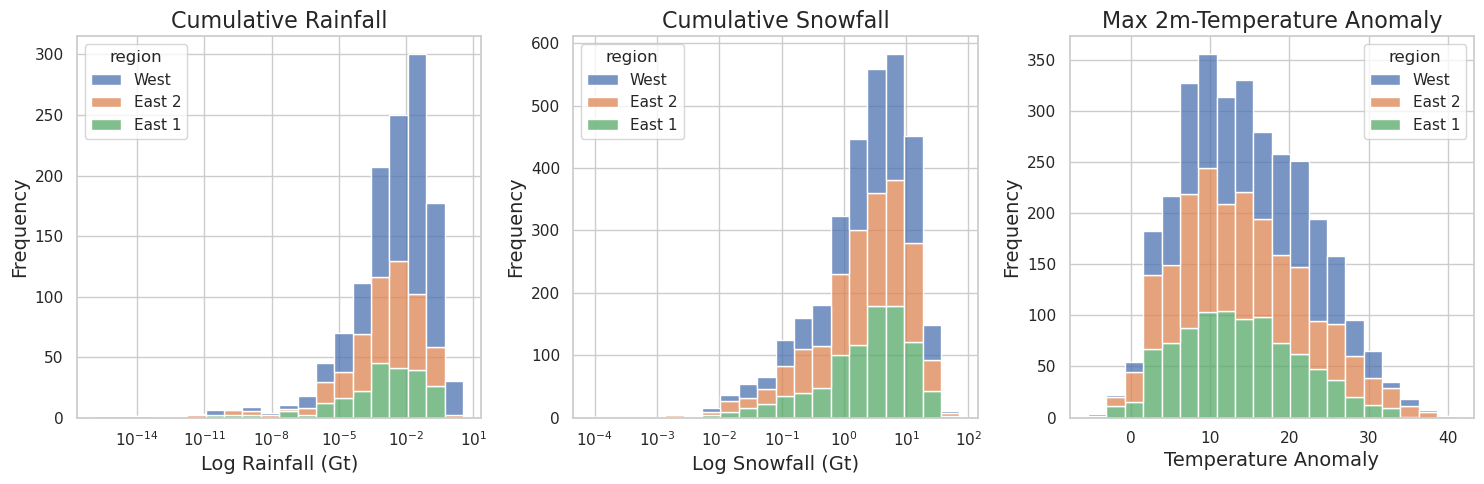

In [30]:
sns.set_theme(style="whitegrid")

# create a figure with 3 subplots arranged in 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# define the column name that contains your regions
region_col = 'region'

# histogram 1: cumulative rainfall (log scale)
sns.histplot(data=dataset, x='cumulative_rainfall_ais', hue=region_col, multiple='stack', bins=20, log_scale=True, ax=axes[0])
axes[0].set_title('Cumulative Rainfall', fontsize=16)
axes[0].set_xlabel('Log Rainfall (Gt)', fontsize=14)
axes[0].set_ylabel('Frequency', fontsize=14)

# histogram 2: cumulative snowfall (log scale)
sns.histplot(data=dataset, x='cumulative_snowfall_ais', hue=region_col, multiple='stack', bins=20, log_scale=True, ax=axes[1])
axes[1].set_title('Cumulative Snowfall', fontsize=16)
axes[1].set_xlabel('Log Snowfall (Gt)', fontsize=14)
axes[1].set_ylabel('Frequency', fontsize=14)

# histogram 3: max T2M anomaly (untransformed)
# Note: Changed data=res to data=dataset assuming 'res' was a typo, change back if 'res' is a separate dataframe
sns.histplot(data=dataset, x='max_T2M_anomaly_ais', hue=region_col, multiple='stack', bins=20, ax=axes[2])
axes[2].set_title('Max 2m-Temperature Anomaly', fontsize=16)
axes[2].set_xlabel('Temperature Anomaly', fontsize=14)
axes[2].set_ylabel('Frequency', fontsize=14)

# automatically adjust spacing between subplots
plt.tight_layout()

# display the plot
fig.savefig('../output/plots/impact_distributions_regional.png', dpi=300)

We find that most of the rainfall events occur in West Antarctica, and that the share of cumulative snowfall events and max 2m temperature anomaly events are pretty evenly spread across the three regions. Perhaps one insight that can be gathered is that more extreme temperature anomalies tend to occur in East 2 over the other two regions of Antarctica.

For a more geographic interpretation of this plot, let's look at the spatial distribution of trajectories of the AR events with the most rainfall, snowfall, and greatest 2m-temperature anomaly.

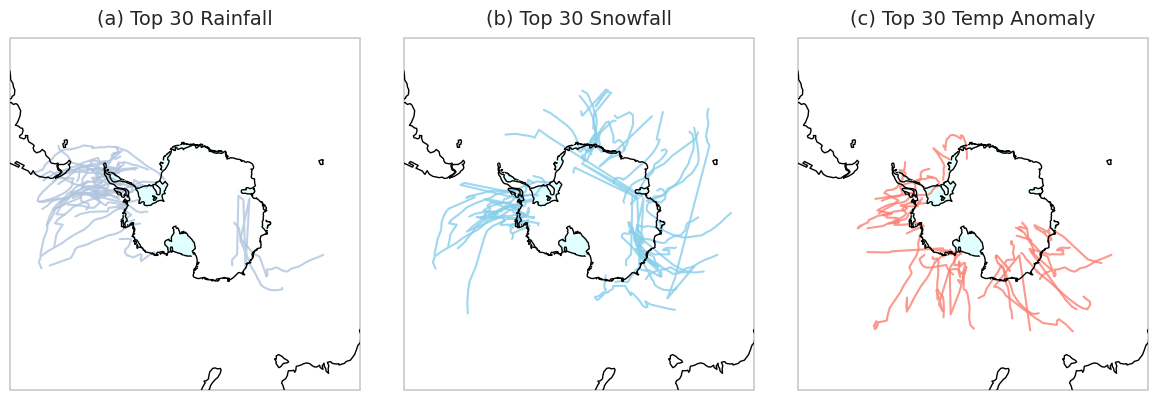

In [31]:
top_n = 30
top_rain = dataset.nlargest(top_n, 'cumulative_rainfall_ais')
top_snow = dataset.nlargest(top_n, 'cumulative_snowfall_ais')
top_temp = dataset.nlargest(top_n, 'max_T2M_anomaly_ais')

# group them into lists for easy looping
top_datasets = [top_rain, top_snow, top_temp]
titles = [f'(a) Top {top_n} Rainfall', f'(b) Top {top_n} Snowfall', f'(c) Top {top_n} Temp Anomaly']
colors = ['lightsteelblue', 'skyblue', 'salmon']

fig, axes = plt.subplots(
    1, 3, 
    figsize=(12, 4), 
    subplot_kw={'projection': ccrs.Stereographic(central_longitude=0., central_latitude=-90.)}
)

for ax, data, title, color in zip(axes, top_datasets, titles, colors):
    
    # add geographic features to the current axis
    ice_shelf_poly = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_polys', '50m', edgecolor='none', facecolor='lightcyan') 
    ax.add_feature(ice_shelf_poly, linewidth=3)
    
    ice_shelf_line = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_lines', '50m', edgecolor='black', facecolor='none') 
    ax.add_feature(ice_shelf_line, linewidth=1, zorder=13)
    
    ax.coastlines(resolution='110m', linewidth=1, zorder=32)
    ax.set_extent([-180, 180, -90, -42], ccrs.PlateCarree())
    ax.set_title(title, fontsize=14, pad=10)

    # plot trajectories for this specific dataset
    for index, row in data.iterrows():
        trajectory = row.trajectory
        ax.plot(trajectory.avg_lon, trajectory.avg_lat, 
                transform=ccrs.Geodetic(), 
                color=color, 
                alpha=0.8, 
                linewidth=1.5)

# automatically adjust spacing so the maps don't overlap
plt.tight_layout()

fig.savefig('../output/plots/most_extreme_tracks.png', dpi=300)

It seems like almost all of the top 30 rainfall events make landfall in the Antarctic peninsula, while the top 30 snowfall events seem more evenly distributed across West Antarctica and East 1 and East 2, with a sizeable gap near the Ross Ice Shelf. The 2m-temperature anomaly trajectories seem to be much more focused on on the Antarctic peninsula of course, but also on East 2 as opposed to East 1.

Finally, let's explore some temporal trends in these values as well.

In [32]:
dataset['landfalling_year'] = dataset.start_date.dt.year

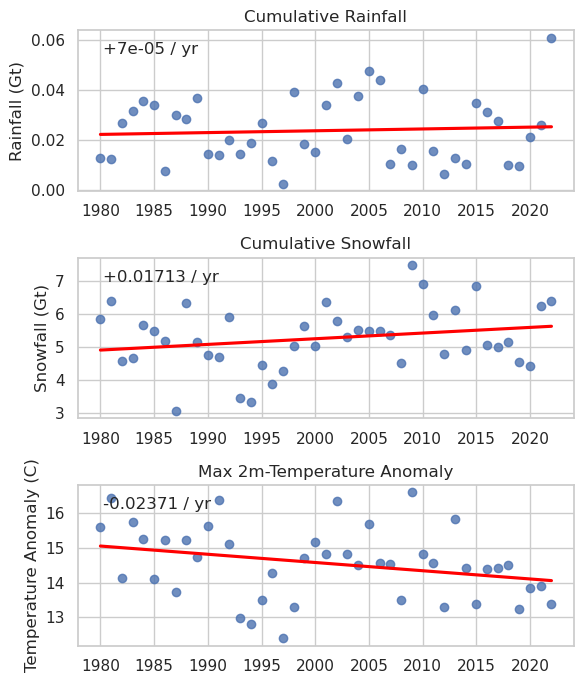

In [34]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(6, 7))

variables = ['cumulative_rainfall_ais', 'cumulative_snowfall_ais', 'max_T2M_anomaly_ais']
titles = ['Cumulative Rainfall', 'Cumulative Snowfall', 'Max 2m-Temperature Anomaly']
ylabels = ['Rainfall (Gt)', 'Snowfall (Gt)', 'Temperature Anomaly (C)']

yearly_avg = dataset.groupby('landfalling_year')[variables].mean().reset_index()

for i in range(3):
    cur_ax = axs[i]
    var = variables[i]
    
    sns.regplot(data=yearly_avg, x='landfalling_year', y=var, ci=None, line_kws={"color": "red"}, ax=cur_ax)
    
    slope = round(stats.linregress(yearly_avg['landfalling_year'], yearly_avg[var])[0], 5)
    
    sign = '+' if slope > 0 else ''
    text = f'{sign}{slope} / yr'
    
    cur_ax.set_title(titles[i])
    cur_ax.set_xticks(np.arange(1980, 2021, 5))

    cur_ax.text(0.05, 0.85, s=text, fontsize=12, transform=cur_ax.transAxes)
    
    cur_ax.set_xlabel('')
    cur_ax.set_ylabel(ylabels[i])
    cur_ax.grid(True)

fig.tight_layout()

fig.savefig('../output/plots/impact_trends_antarctic_wide_averaged.png', dpi=300)